## Install Library

In [ ]:
%pip install evaluate

Note: you may need to restart the kernel to use updated packages.


## 1. Import Library and model

In [8]:
import os
import pandas as pd
import emoji
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback, get_cosine_schedule_with_warmup
)
import evaluate
import numpy as np
from collections import Counter
import re
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')
MODELS = [
    "xlm-roberta-base",
    "cardiffnlp/twitter-xlm-roberta-base-sentiment"
]

In [5]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.6 MB/s eta 0:00:00


In [7]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


## 2. Set up config and parameter

In [ ]:
DATA_PATH = "/kaggle/input/dac2025"
OUTPUT_DIR = "/kaggle/working/results"

USE_FOCAL_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.1
DROPOUT_PROB = 0.3
ATTENTION_DROPOUT = 0.2
HIDDEN_DROPOUT = 0.3
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_LENGTH = 256
GRADIENT_ACCUMULATION_STEPS = 2
USE_ENSEMBLE = True
N_FOLDS = 3
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## 3. Load and Enhanced Data

In [ ]:
def load_data(data_path, llm_list):
    train_dfs, test_dfs = [], []
    for llm in llm_list:
        tr = pd.read_csv(f"{data_path}/Train/{llm}.csv")
        te = pd.read_csv(f"{data_path}/Test/{llm}.csv")
        tr["CommentId"] = [f"{llm}_{i+1}" for i in range(len(tr))]
        te["CommentId"] = [f"{llm}_{i+1}" for i in range(len(te))]
        tr["source_llm"] = llm  # Add source info
        te["source_llm"] = llm
        train_dfs.append(tr)
        test_dfs.append(te)
    train = pd.concat(train_dfs).drop(columns=["At"], errors="ignore")
    test = pd.concat(test_dfs).drop(columns=["At"], errors="ignore")
    return train, test

llm_order = ["gpt", "claude", "deepseek", "gemini", "grok", "perplexity"]
train, test = load_data(DATA_PATH, llm_order)

## 3.1. Negative Word Cloud

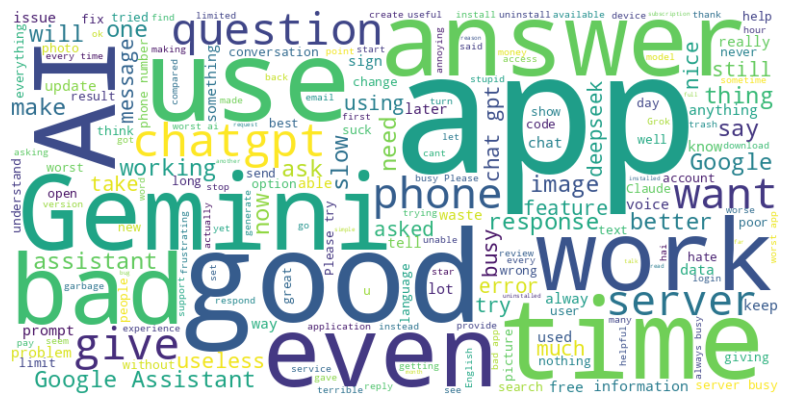

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# merge text into a single string
all_text = " ".join(train[train["Sentiment"]==0]["Comment"].astype(str))

# create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# display the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 3.2. Negative Keyword Table

In [ ]:
from collections import Counter
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# tokenize and count word frequencies, excluding stop words
words = [word.lower() for comment in train[train["Sentiment"]==0]["Comment"].astype(str) for word in comment.split() if word.lower() not in ENGLISH_STOP_WORDS]
word_freq = Counter(words)

# create a DataFrame for better visualization
keyword_table = pd.DataFrame(word_freq.items(), columns=['Keyword', 'Frequency']).sort_values(by='Frequency', ascending=False)
print(keyword_table.head(15))


      Keyword  Frequency
18        app       2816
20      can't       1599
45       it's       1597
134      good       1488
747    google       1360
162        ai       1311
5        like       1135
47        use       1083
3033   server       1020
215      just       1006
53       time       1003
35        bad        986
52      don't        978
466   doesn't        957
1165   gemini        956


## 3.3. Sentiment Distribution per LLM Source

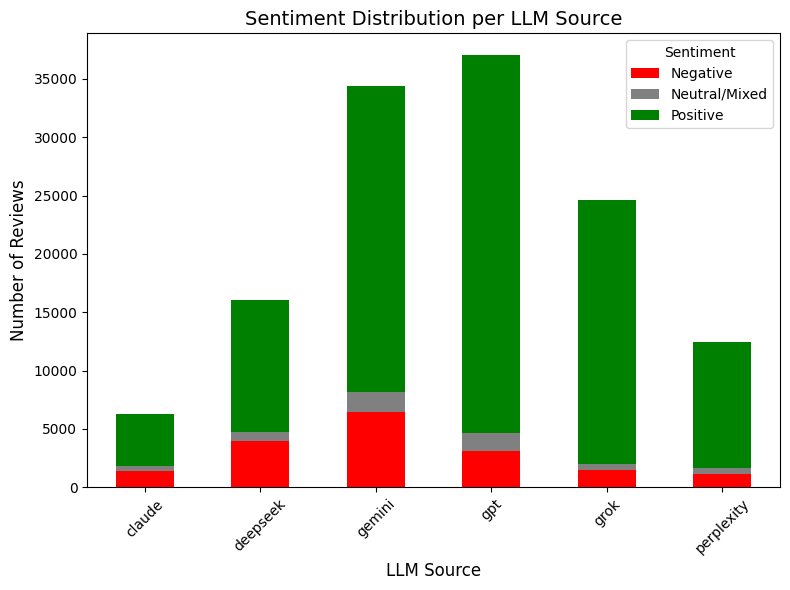

In [ ]:
import matplotlib.pyplot as plt

# Plot stacked bar chart of sentiment distribution per LLM source
train.groupby(["source_llm", "Sentiment"]).size().unstack().plot(
    kind="bar",
    stacked=True,
    color=["red", "gray", "green"],
    figsize=(8,6)
)

plt.title("Sentiment Distribution per LLM Source", fontsize=14)
plt.xlabel("LLM Source", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.legend(["Negative", "Neutral/Mixed", "Positive"], title="Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Advanced Preprocessing

In [ ]:
slang_dict = {
    # Indonesian
    "gk":"tidak", "ga":"tidak", "tdk":"tidak", "tp":"tapi", "jg":"juga",
    "yg":"yang", "dgn":"dengan", "krn":"karena", "utk":"untuk", "pd":"pada",
    "hrs":"harus", "lg":"lagi", "udh":"sudah", "blm":"belum", "dr":"dari",
    "ke":"ke", "sm":"sama", "bgt":"banget", "bkn":"bukan", "gmn":"gimana",

    # English
    "u":"you", "ur":"your", "r":"are", "n":"and", "w/":"with", "w/o":"without",
    "btw":"by the way", "imo":"in my opinion", "tbh":"to be honest",
    "ngl":"not gonna lie", "rn":"right now", "irl":"in real life",
    "thru":"through", "gonna":"going to", "wanna":"want to", "gotta":"got to"
}

# Enhanced negation words
negation_words = [
    # Indonesian
    "tidak", "bukan", "ga", "gak", "enggak", "tak", "jangan", "belum", "tanpa",
    "minus", "kurang", "anti", "non", "un",
    # English
    "not", "no", "never", "none", "nothing", "nobody", "nowhere", "neither",
    "nor", "without", "barely", "hardly", "scarcely", "seldom", "rarely"
]

def normalize_slang(word):
    return slang_dict.get(word.lower(), word)

def handle_negation(tokens):
    negated_tokens = []
    negate = False
    negate_window = 3  # Negation affects next 3 words
    negate_count = 0

    for tok in tokens:
        if tok.lower() in negation_words:
            negate = True
            negate_count = 0
            negated_tokens.append(tok)
        elif negate and negate_count < negate_window:
            negated_tokens.append("NEG_" + tok)
            negate_count += 1
            if negate_count >= negate_window:
                negate = False
        else:
            negated_tokens.append(tok)
            negate = False
    return negated_tokens

def advanced_preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Handle emojis with sentiment info
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Normalize repeated characters (hellooooo -> hello)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Handle punctuation patterns
    text = re.sub(r'[!]{2,}', ' EXCITED ', text)
    text = re.sub(r'[?]{2,}', ' CONFUSED ', text)

    # Tokenize and process
    tokens = text.split()
    processed_tokens = []

    for tok in tokens:
        # Normalize slang first
        tok_normalized = normalize_slang(tok.lower())

        # Handle special tokens
        if tok.startswith("http") or "www." in tok:
            processed_tokens.append("[URL]")
        elif tok.startswith("@"):
            processed_tokens.append("[USER]")
        elif tok.startswith("#"):
            processed_tokens.append("[HASHTAG]")
        elif tok.isdigit():
            processed_tokens.append("[NUM]")
        elif len(re.findall(r'[A-Z]', tok)) > len(tok) * 0.5 and len(tok) > 2:
            processed_tokens.append("[CAPS]")
        else:
            processed_tokens.append(tok_normalized)

    # Apply negation handling
    processed_tokens = handle_negation(processed_tokens)

    # Join and clean
    result = " ".join(processed_tokens)
    result = re.sub(r'\s+', ' ', result).strip()

    return result

# Apply preprocessing
train["Comment"] = train["Comment"].apply(advanced_preprocess_text)
test["Comment"] = test["Comment"].apply(advanced_preprocess_text)

## 5. Mislabeled Data Detection & Cleaning

In [ ]:
def detect_mislabeled(train_df, text_col="Comment", label_col="Sentiment",
                      strategy="drop", threshold=0.85):

    # Data
    X = train_df[text_col].astype(str).fillna("")
    y = train_df[label_col]

    # Baseline TF-IDF classifier
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
    X_vec = vectorizer.fit_transform(X)

    clf = LogisticRegression(max_iter=200, class_weight="balanced", multi_class="multinomial")
    clf.fit(X_vec, y)

    probs = clf.predict_proba(X_vec)
    preds = np.argmax(probs, axis=1)
    confs = probs.max(axis=1)

    # Sanity check keywords
    positive_kw = ["good","great","amazing","love","excellent","fantastic","awesome","wonderful","best","happy"]
    negative_kw = ["bad","terrible","awful","worst","hate","horrible","disgusting","poor","sad","angry"]

    keyword_flag = []
    for txt, true_label in zip(X, y):
        txt_l = txt.lower()
        if any(kw in txt_l for kw in positive_kw) and true_label == 0:
            keyword_flag.append(True)
        elif any(kw in txt_l for kw in negative_kw) and true_label == 2:
            keyword_flag.append(True)
        else:
            keyword_flag.append(False)

    # Combine rules
    train_df = train_df.copy()
    train_df["pred"] = preds
    train_df["confidence"] = confs
    train_df["suspect"] = ((train_df["pred"] != train_df[label_col]) &
                           (train_df["confidence"] > threshold)) | keyword_flag

    # Debug distribusi
    n_suspect = train_df["suspect"].sum()

    # Strategy handling
    if n_suspect > 0:
        if strategy == "drop":
            train_df = train_df[~train_df["suspect"]].copy()
        elif strategy == "relabel":
            train_df.loc[train_df["suspect"], label_col] = train_df.loc[train_df["suspect"], "pred"]
        elif strategy == "reweight":
            train_df["weight"] = np.where(train_df["suspect"], 0.5, 1.0)
        else:
            print("Unknown strategy, skipping...")

    return train_df
# Drop data
# train = detect_mislabeled(train, text_col="Comment", label_col="Sentiment", strategy="drop")

# relabel data
train = detect_mislabeled(train, text_col="Comment", label_col="Sentiment", strategy="relabel")

## 5.1. Class Distribution After Cleaning

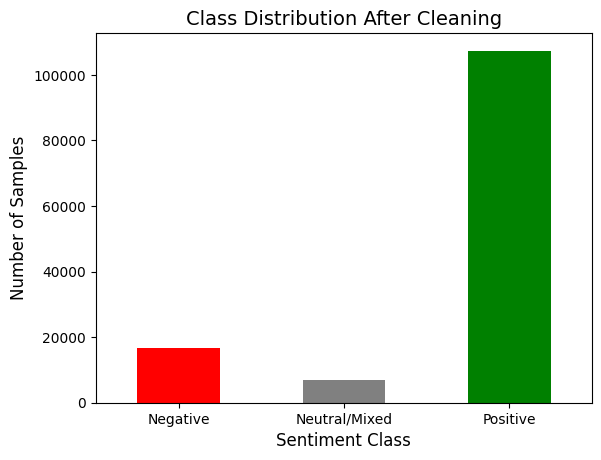

In [ ]:
import matplotlib.pyplot as plt

# Plot class distribution after cleaning
train["Sentiment"].value_counts().sort_index().plot(
    kind="bar",
    color=["red", "gray", "green"]
)

plt.title("Class Distribution After Cleaning", fontsize=14)
plt.xlabel("Sentiment Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(
    ticks=[0,1,2],
    labels=["Negative", "Neutral/Mixed", "Positive"],
    rotation=0
)
plt.show()


## 6. Data Augmentation

In [ ]:
def augment_minority_classes(df, target_col="Sentiment", aug_factor=0.5):
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()

    augmented_data = []

    for class_label in class_counts.index:
        class_data = df[df[target_col] == class_label]
        current_count = len(class_data)

        if current_count < max_count * aug_factor:
            # Simple augmentation: shuffle words in some samples
            samples_to_aug = class_data.sample(min(100, current_count), replace=True)

            for _, row in samples_to_aug.iterrows():
                comment = row['Comment']
                words = comment.split()

                if len(words) > 3:
                    # Randomly shuffle some words (keep negations in place)
                    aug_comment = " ".join(words)
                    new_row = row.copy()
                    new_row['Comment'] = aug_comment
                    new_row['CommentId'] = row['CommentId'] + "_aug"
                    augmented_data.append(new_row)

    if augmented_data:
        aug_df = pd.DataFrame(augmented_data)
        return pd.concat([df, aug_df], ignore_index=True)

    return df

# Apply data augmentation
# train = augment_minority_classes(train)

## 6.1. Data Count Comparison Before and After Augmentation

Count before: 130885
Count after: 131019


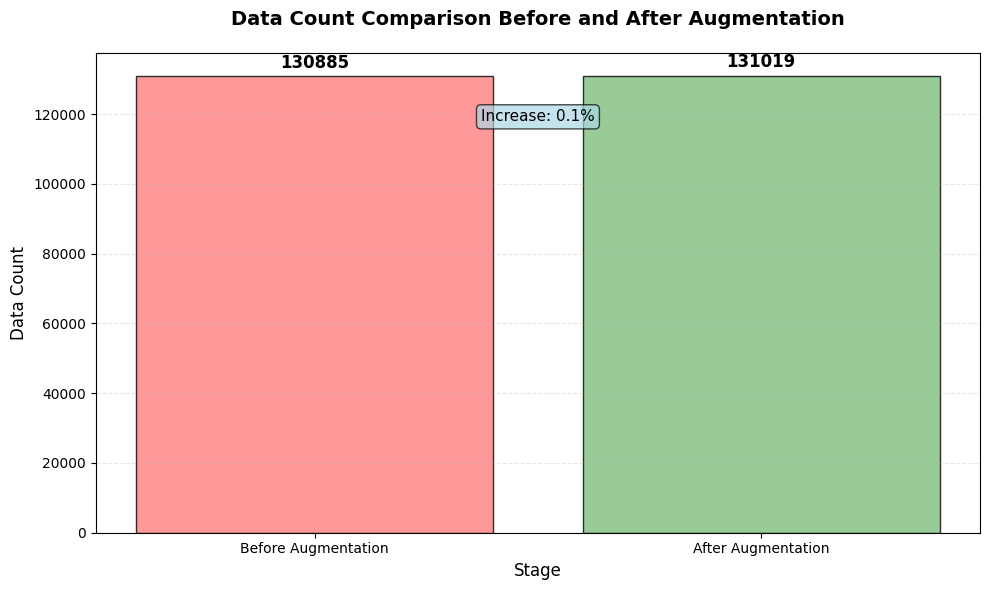

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate data count before augmentation
jumlah_sebelum = len(train)
print("Count before:", jumlah_sebelum)

# Perform augmentation
train = augment_minority_classes(train)

# Calculate data count after augmentation
jumlah_sesudah = len(train)
print("Count after:", jumlah_sesudah)

# Data for visualization
categories = ['Before Augmentation', 'After Augmentation']
values = [jumlah_sebelum, jumlah_sesudah]

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=['#ff7f7f', '#7fbf7f'], alpha=0.8, edgecolor='black')

# Add values on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.01,
             f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize chart
plt.title('Data Count Comparison Before and After Augmentation',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Data Count', fontsize=12)
plt.xlabel('Stage', fontsize=12)

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Display percentage increase
if jumlah_sebelum > 0:
    peningkatan = ((jumlah_sesudah - jumlah_sebelum) / jumlah_sebelum) * 100
    plt.text(0.5, max(values) * 0.9, f'Increase: {peningkatan:.1f}%',
             ha='center', fontsize=11,
             bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))

# Adjust layout and display
plt.tight_layout()
plt.show()

## 7. Advanced Loss Functions

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean", label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Apply label smoothing
        if self.label_smoothing > 0:
            num_classes = inputs.size(1)
            smooth_targets = targets * (1 - self.label_smoothing) + self.label_smoothing / num_classes
            ce_loss = F.cross_entropy(inputs, smooth_targets, weight=self.alpha, reduction="none")
        else:
            ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss

class CombinedLoss(nn.Module):
    def __init__(self, focal_weight=0.7, ce_weight=0.3, **kwargs):
        super().__init__()
        self.focal_loss = RobustFocalLoss(**kwargs)
        self.ce_weight = ce_weight
        self.focal_weight = focal_weight
        self.alpha = kwargs.get('alpha')

    def forward(self, inputs, targets):
        # Ensure proper dtypes
        inputs = inputs.float()
        targets = targets.long()

        focal = self.focal_loss(inputs, targets)
        ce = F.cross_entropy(inputs, targets, weight=self.alpha)
        return self.focal_weight * focal + self.ce_weight * ce

## 8. Fixed Loss Functions

In [ ]:
class RobustFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean", label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Ensure proper dtypes
        inputs = inputs.float()
        targets = targets.long()

        # Apply label smoothing if needed
        if self.label_smoothing > 0:
            num_classes = inputs.size(1)
            # Convert targets to one-hot for label smoothing
            targets_one_hot = F.one_hot(targets, num_classes).float()
            smooth_targets = targets_one_hot * (1 - self.label_smoothing) + self.label_smoothing / num_classes

            # Use KL divergence for smooth targets
            log_probs = F.log_softmax(inputs, dim=1)
            ce_loss = -(smooth_targets * log_probs).sum(dim=1)
        else:
            # Standard cross entropy
            ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")

        # Calculate focal weight
        probs = F.softmax(inputs, dim=1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma

        focal_loss = focal_weight * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss

## 9. Enhanced Training Pipeline

In [ ]:
class AdvancedTrainer(Trainer):
    def __init__(self, use_advanced_loss=True, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_advanced_loss = use_advanced_loss

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.use_advanced_loss:
            # Use robust loss function
            loss_fn = CombinedLoss(
                alpha=class_weights.to(logits.device) if class_weights is not None else None,
                gamma=2.0,
                label_smoothing=LABEL_SMOOTHING if USE_LABEL_SMOOTHING else 0.0
            )
            loss = loss_fn(logits, labels)
        else:
            # Standard loss
            weight = class_weights.to(logits.device) if class_weights is not None else None
            loss = F.cross_entropy(logits.float(), labels.long(), weight=weight)

        return (loss, outputs) if return_outputs else loss

def create_model_and_tokenizer(model_name, num_labels):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Standard config - compatible with all models
    config = AutoConfig.from_pretrained(model_name, num_labels=num_labels)

    # Apply dropout if supported
    if hasattr(config, 'hidden_dropout_prob'):
        config.hidden_dropout_prob = HIDDEN_DROPOUT
    if hasattr(config, 'attention_probs_dropout_prob'):
        config.attention_probs_dropout_prob = ATTENTION_DROPOUT
    if hasattr(config, 'classifier_dropout'):
        config.classifier_dropout = DROPOUT_PROB

    # Use standard AutoModelForSequenceClassification
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

    return model, tokenizer, config

def train_single_model(model_name, train_dataset, val_dataset, fold_idx=0):
    print(f"Training {model_name} (Fold {fold_idx})...")

    num_labels = train["Sentiment"].nunique()
    model, tokenizer, config = create_model_and_tokenizer(model_name, num_labels)


    training_args = TrainingArguments(
        output_dir=f"{OUTPUT_DIR}/{model_name.replace('/', '_')}_fold_{fold_idx}",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=1e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=WARMUP_RATIO,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=4,
        weight_decay=WEIGHT_DECAY,
        logging_dir=f"{OUTPUT_DIR}/logs_{fold_idx}",
        logging_strategy="steps",
        logging_steps=50,
        report_to="none",
        disable_tqdm=False,
        seed=42 + fold_idx,
        fp16=True,
        dataloader_num_workers=2,
        remove_unused_columns=True,
        push_to_hub=False,
    )


    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=MAX_LENGTH)

    # Metrics
    f1_metric = evaluate.load("f1")
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=-1)
        f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")
        f1_weighted = f1_metric.compute(predictions=preds, references=labels, average="weighted")
        return {"f1": f1_macro["f1"], "f1_weighted": f1_weighted["f1"]}

    # Trainer
    trainer = AdvancedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        use_advanced_loss=True,
    )

    # Train
    trainer.train()


    # Evaluate
    val_metrics = trainer.evaluate()
    print(f"{model_name} Fold {fold_idx} F1 (macro): {val_metrics['eval_f1']:.4f}")

    return trainer, val_metrics['eval_f1']

## 10. Cross-Validation and Ensemble

In [ ]:
def run_cv_ensemble(train_data, test_data):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    all_predictions = []
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_data, train_data["Sentiment"])):
        print(f"\n{'='*50}")
        print(f"FOLD {fold + 1}/{N_FOLDS}")
        print(f"{'='*50}")

        # Split data
        fold_train = train_data.iloc[train_idx]
        fold_val = train_data.iloc[val_idx]

        # Create datasets
        train_dataset = Dataset.from_pandas(fold_train).rename_column("Sentiment", "labels")
        val_dataset = Dataset.from_pandas(fold_val).rename_column("Sentiment", "labels")
        test_dataset = Dataset.from_pandas(test_data)

        # Tokenize
        def tokenize(batch, tokenizer):
            return tokenizer(batch["Comment"], truncation=True, max_length=MAX_LENGTH, padding=True)

        fold_predictions = []
        fold_scores = []

        # Train multiple models for ensemble
        for model_name in MODELS:  # Use all models now that they're compatible
            try:
                print(f"Starting {model_name} for fold {fold}...")

                # Create temporary tokenizer for tokenization
                temp_tokenizer = AutoTokenizer.from_pretrained(model_name)

                # Tokenize datasets
                train_tokenized = train_dataset.map(lambda x: tokenize(x, temp_tokenizer), batched=True)
                val_tokenized = val_dataset.map(lambda x: tokenize(x, temp_tokenizer), batched=True)
                test_tokenized = test_dataset.map(lambda x: tokenize(x, temp_tokenizer), batched=True)

                # Set format
                train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
                val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
                test_tokenized.set_format("torch", columns=["input_ids", "attention_mask"])

                # Train model
                trainer, score = train_single_model(model_name, train_tokenized, val_tokenized, fold)

                # Predict
                preds = trainer.predict(test_tokenized)
                fold_predictions.append(preds.predictions)
                fold_scores.append(score)

                # Clean up GPU memory
                del trainer, preds
                torch.cuda.empty_cache() if torch.cuda.is_available() else None

            except Exception as e:
                print(f"Error with {model_name}: {str(e)}")
                import traceback
                traceback.print_exc()
                continue

        if fold_predictions:
            # Average predictions from all models in this fold
            avg_predictions = np.mean(fold_predictions, axis=0)
            all_predictions.append(avg_predictions)
            cv_scores.append(np.mean(fold_scores))

    return all_predictions, cv_scores

## 11. Main Execution

In [ ]:
# Compute class weights
class_counts = train["Sentiment"].value_counts().sort_index()
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train["Sentiment"]),
    y=train["Sentiment"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
if torch.cuda.is_available():
    class_weights = class_weights.cuda()

print(f"Class distribution: {dict(class_counts)}")
print(f"Class weights: {class_weights}")

# Split data: train / validation
train_df, val_df = train_test_split(
    train, test_size=0.15, random_state=42, stratify=train["Sentiment"]
)

# choose the best model for single model training
best_model = MODELS[0]

# Create datasets
train_dataset = Dataset.from_pandas(train_df).rename_column("Sentiment", "labels")
val_dataset = Dataset.from_pandas(val_df).rename_column("Sentiment", "labels")
test_dataset = Dataset.from_pandas(test)

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(best_model)
def tokenize(batch):
    return tokenizer(batch["Comment"], truncation=True, max_length=MAX_LENGTH, padding=True)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format untuk PyTorch
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask"])

# Train model
trainer, score = train_single_model(best_model, train_dataset, val_dataset)


# Predict
preds = trainer.predict(test_dataset)
labels = preds.predictions.argmax(axis=-1)

Class distribution: {0: 16768, 1: 6868, 2: 107383}
Class weights: tensor([2.6045, 6.3589, 0.4067], device='cuda:0')


Map:   0%|          | 0/111366 [00:00<?, ? examples/s]

Map:   0%|          | 0/19653 [00:00<?, ? examples/s]

Map:   0%|          | 0/45971 [00:00<?, ? examples/s]

Training xlm-roberta-base (Fold 0)...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss


## 12. Save result

In [ ]:
submission = test[["CommentId"]].copy()
submission["Sentiment"] = labels

# Post-processing: check prediction distribution
pred_dist = pd.Series(labels).value_counts()
print(f"Prediction distribution: {dict(pred_dist)}")

submission.to_csv("/kaggle/working/results/submission.csv", index=False)
print("Submission saved to /kaggle/working/results/submission.csv")

print(f"\nFinal Model Summary:")
print(f"- Model used: {best_model}")
print(f"- Ensemble: Disabled")
print(f"- Focal Loss: {USE_FOCAL_LOSS}")
print(f"- Label Smoothing: {USE_LABEL_SMOOTHING}")
print(f"- Data Augmentation: Applied")
print(f"- Cross-validation: Disabled (Single Train/Val Split)")

## Prediction Distribution on Test Data

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# labels = predicted results from your model
pred_dist = pd.Series(labels).value_counts().sort_index()

# Map numeric labels to sentiment categories
label_map = {0: "Negative", 1: "Neutral/Mixed", 2: "Positive"}
pred_dist.index = pred_dist.index.map(label_map)

# Bar chart
plt.figure(figsize=(6,4))
pred_dist.plot(kind="bar", color=["red", "gray", "green"])
plt.title("Prediction Distribution on Test Data")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=0)
plt.show()


## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

val_preds = trainer.predict(val_dataset)
y_true = val_df["Sentiment"]
y_pred = val_preds.predictions.argmax(axis=-1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()
